# 📊 JoSan Filter Test Results Visualization

## Regex-Only vs AI-Enhanced Multilingual Testing

This notebook compares the performance of two filtering approaches:
1. **Regex-Only** (Bloom Filter + Trie + Text Normalization)
2. **AI-Enhanced** (Regex + OpenAI Moderation + GPT-4o-mini Contextual)

### Test Configuration
- **Total Tests**: 300 per approach
- **Languages**: English (100), Tagalog (100), Bisaya (100)
- **Categories**: Scunthorpe, gaming, threats, hate speech, bullying, etc.

---

## 1. Import Libraries & Configuration

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from dataclasses import dataclass
from typing import Optional

# Configure plotting
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Color scheme
COLORS = {
    'regex': '#3498db',     # Blue
    'ai': '#2ecc71',        # Green
    'english': '#e74c3c',   # Red
    'tagalog': '#f39c12',   # Orange
    'bisaya': '#9b59b6',    # Purple
    'correct': '#27ae60',   # Green
    'incorrect': '#c0392b'  # Red
}

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 2. Data Classes for Test Results

In [2]:
@dataclass
class LanguageMetrics:
    """Metrics for a specific language"""
    name: str
    total: int
    correct: int
    accuracy: float
    clean_correct: int
    clean_total: int
    toxic_correct: int
    toxic_total: int
    precision: float
    recall: float
    f1_score: float
    avg_latency_ms: float

@dataclass
class CategoryMetrics:
    """Metrics for a specific category"""
    name: str
    correct: int
    total: int
    accuracy: float

@dataclass
class TestResults:
    """Complete test results for an approach"""
    approach_name: str
    total_tests: int
    correct: int
    accuracy: float
    precision: float
    recall: float
    f1_score: float
    avg_latency_ms: float
    languages: dict[str, LanguageMetrics]
    categories: dict[str, CategoryMetrics]
    false_positives: int
    false_negatives: int

print("✅ Data classes defined!")

✅ Data classes defined!


## 3. Parse Test Output Files

In [5]:
def parse_percentage(s: str) -> float:
    """Extract percentage from string like '75.33%' or '75.33'"""
    match = re.search(r'([\d.]+)\s*%?', s)
    return float(match.group(1)) if match else 0.0

def parse_fraction(s: str) -> tuple[int, int]:
    """Extract correct/total from string like '74/100'"""
    match = re.search(r'(\d+)/(\d+)', s)
    return (int(match.group(1)), int(match.group(2))) if match else (0, 0)

def parse_latency(s: str) -> float:
    """Extract latency from string like '0.267ms' or '952ms'"""
    match = re.search(r'([\d.]+)\s*ms', s)
    return float(match.group(1)) if match else 0.0

def parse_test_output(file_path: Path, approach_name: str) -> TestResults:
    """Parse the test output file and extract metrics"""
    content = file_path.read_text(encoding='utf-8')
    
    # Extract overall metrics from FINAL SUMMARY section
    # Look for the KEY METRICS section
    summary_section = re.search(r'KEY METRICS.*?BY LANGUAGE', content, re.DOTALL)
    if summary_section:
        summary_text = summary_section.group(0)
    else:
        summary_text = content
    
    overall_accuracy = parse_percentage(re.search(r'Overall Accuracy:\s*([\d.]+)%', summary_text).group(1) if re.search(r'Overall Accuracy:\s*([\d.]+)%', summary_text) else '0')
    precision = parse_percentage(re.search(r'Precision:\s*([\d.]+)%', summary_text).group(1) if re.search(r'Precision:\s*([\d.]+)%', summary_text) else '0')
    recall = parse_percentage(re.search(r'Recall:\s*([\d.]+)%', summary_text).group(1) if re.search(r'Recall:\s*([\d.]+)%', summary_text) else '0')
    f1_score = parse_percentage(re.search(r'F1 Score:\s*([\d.]+)%', summary_text).group(1) if re.search(r'F1 Score:\s*([\d.]+)%', summary_text) else '0')
    latency_match = re.search(r'Average Latency:\s*([\d.]+)\s*ms', summary_text)
    avg_latency = float(latency_match.group(1)) if latency_match else 0.0
    
    # Extract error counts from ERROR ANALYSIS section
    fp_match = re.search(r'False Positives.*?:\s*(\d+)', content)
    fn_match = re.search(r'False Negatives.*?:\s*(\d+)', content)
    false_positives = int(fp_match.group(1)) if fp_match else 0
    false_negatives = int(fn_match.group(1)) if fn_match else 0
    
    # Extract language metrics from BY LANGUAGE section
    languages = {}
    for lang in ['ENGLISH', 'TAGALOG', 'BISAYA']:
        # Find the language section and extract metrics
        lang_section = re.search(rf'🌐 {lang}.*?(?=🌐|════════)', content, re.DOTALL)
        if lang_section:
            lang_text = lang_section.group(0)
            
            # Extract individual metrics
            overall = re.search(r'Overall:\s*(\d+)/(\d+)', lang_text)
            clean = re.search(r'Clean:\s*(\d+)/(\d+)', lang_text)
            toxic = re.search(r'Toxic:\s*(\d+)/(\d+)', lang_text)
            prec = re.search(r'Precision:\s*([\d.]+)%', lang_text)
            rec = re.search(r'Recall:\s*([\d.]+)%', lang_text)
            f1 = re.search(r'F1 Score:\s*([\d.]+)%', lang_text)
            lat = re.search(r'Avg Latency:\s*([\d.]+)\s*ms', lang_text)
            
            if overall and clean and toxic:
                correct, total = int(overall.group(1)), int(overall.group(2))
                clean_c, clean_t = int(clean.group(1)), int(clean.group(2))
                toxic_c, toxic_t = int(toxic.group(1)), int(toxic.group(2))
                languages[lang.lower()] = LanguageMetrics(
                    name=lang.lower(),
                    total=total,
                    correct=correct,
                    accuracy=correct/total*100,
                    clean_correct=clean_c,
                    clean_total=clean_t,
                    toxic_correct=toxic_c,
                    toxic_total=toxic_t,
                    precision=float(prec.group(1)) if prec else 0.0,
                    recall=float(rec.group(1)) if rec else 0.0,
                    f1_score=float(f1.group(1)) if f1 else 0.0,
                    avg_latency_ms=float(lat.group(1)) if lat else 0.0
                )
    
    # Extract category metrics from CATEGORY BREAKDOWN section
    categories = {}
    category_pattern = r'│\s*([\w_]+)\s*│\s*(\d+)/(\d+)\s*│\s*([\d]+)\s*%'
    for match in re.finditer(category_pattern, content):
        cat_name = match.group(1).strip()
        correct, total = int(match.group(2)), int(match.group(3))
        categories[cat_name] = CategoryMetrics(
            name=cat_name,
            correct=correct,
            total=total,
            accuracy=correct/total*100 if total > 0 else 0
        )
    
    return TestResults(
        approach_name=approach_name,
        total_tests=300,
        correct=int(overall_accuracy * 3),  # 300 tests
        accuracy=overall_accuracy,
        precision=precision,
        recall=recall,
        f1_score=f1_score,
        avg_latency_ms=avg_latency,
        languages=languages,
        categories=categories,
        false_positives=false_positives,
        false_negatives=false_negatives
    )

print("✅ Parser functions defined!")

✅ Parser functions defined!


## 4. Load Test Results

In [6]:
# Define paths to test output files
RESULTS_DIR = Path('../tests/results/old')
REGEX_FILE = RESULTS_DIR / 'regex-only-test-output.txt'
AI_FILE = RESULTS_DIR / 'multilingual-test-output.txt'

# Parse both test results
regex_results = parse_test_output(REGEX_FILE, "Regex-Only")
ai_results = parse_test_output(AI_FILE, "AI-Enhanced")

print(f"\n📊 REGEX-ONLY RESULTS")
print(f"   Accuracy: {regex_results.accuracy:.2f}%")
print(f"   Precision: {regex_results.precision:.2f}%")
print(f"   Recall: {regex_results.recall:.2f}%")
print(f"   F1 Score: {regex_results.f1_score:.2f}%")
print(f"   Avg Latency: {regex_results.avg_latency_ms:.3f}ms")

print(f"\n🤖 AI-ENHANCED RESULTS")
print(f"   Accuracy: {ai_results.accuracy:.2f}%")
print(f"   Precision: {ai_results.precision:.2f}%")
print(f"   Recall: {ai_results.recall:.2f}%")
print(f"   F1 Score: {ai_results.f1_score:.2f}%")
print(f"   Avg Latency: {ai_results.avg_latency_ms:.3f}ms")


📊 REGEX-ONLY RESULTS
   Accuracy: 75.33%
   Precision: 91.30%
   Recall: 56.00%
   F1 Score: 69.42%
   Avg Latency: 0.221ms

🤖 AI-ENHANCED RESULTS
   Accuracy: 84.67%
   Precision: 95.73%
   Recall: 74.67%
   F1 Score: 83.90%
   Avg Latency: 952.000ms


## 5. Overall Metrics Comparison

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10332\3905611348.py:48: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10332\3905611348.py:48: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10332\3905611348.py:49: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.savefig('../tests/results/overall_comparison.png', dpi=150, bbox_inches='tight')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10332\3905611348.py:49: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.savefig('../tests/results/overall_comparison.png', dpi=150, bbox_inches='tight')
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial

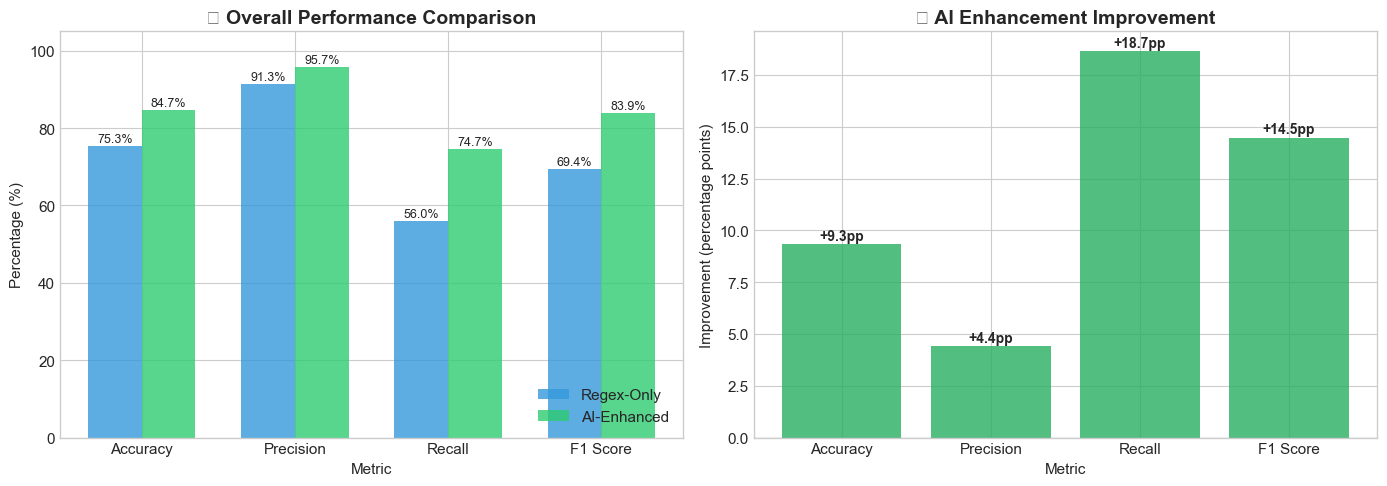


✅ Chart saved to tests/results/overall_comparison.png


In [7]:
# Create comparison DataFrame
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
regex_values = [regex_results.accuracy, regex_results.precision, regex_results.recall, regex_results.f1_score]
ai_values = [ai_results.accuracy, ai_results.precision, ai_results.recall, ai_results.f1_score]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparison
x = np.arange(len(metrics))
width = 0.35

bars1 = axes[0].bar(x - width/2, regex_values, width, label='Regex-Only', color=COLORS['regex'], alpha=0.8)
bars2 = axes[0].bar(x + width/2, ai_values, width, label='AI-Enhanced', color=COLORS['ai'], alpha=0.8)

axes[0].set_xlabel('Metric')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_title('📊 Overall Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend(loc='lower right')
axes[0].set_ylim(0, 105)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    axes[0].annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                     xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    axes[0].annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                     xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

# Improvement delta chart
improvements = [ai_values[i] - regex_values[i] for i in range(len(metrics))]
colors = [COLORS['correct'] if imp > 0 else COLORS['incorrect'] for imp in improvements]
bars3 = axes[1].bar(metrics, improvements, color=colors, alpha=0.8)
axes[1].axhline(y=0, color='gray', linestyle='-', linewidth=0.8)
axes[1].set_xlabel('Metric')
axes[1].set_ylabel('Improvement (percentage points)')
axes[1].set_title('📈 AI Enhancement Improvement', fontsize=14, fontweight='bold')

for bar in bars3:
    height = bar.get_height()
    axes[1].annotate(f'{height:+.1f}pp', xy=(bar.get_x() + bar.get_width()/2, height),
                     xytext=(0, 3 if height > 0 else -12), textcoords="offset points", 
                     ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../tests/results/overall_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved to tests/results/overall_comparison.png")

## 6. Per-Language Performance Comparison

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10332\2042708484.py:62: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10332\2042708484.py:62: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10332\2042708484.py:62: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10332\2042708484.py:62: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10332\2042708484.py:62: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10332\2042708484.py:63: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from fo

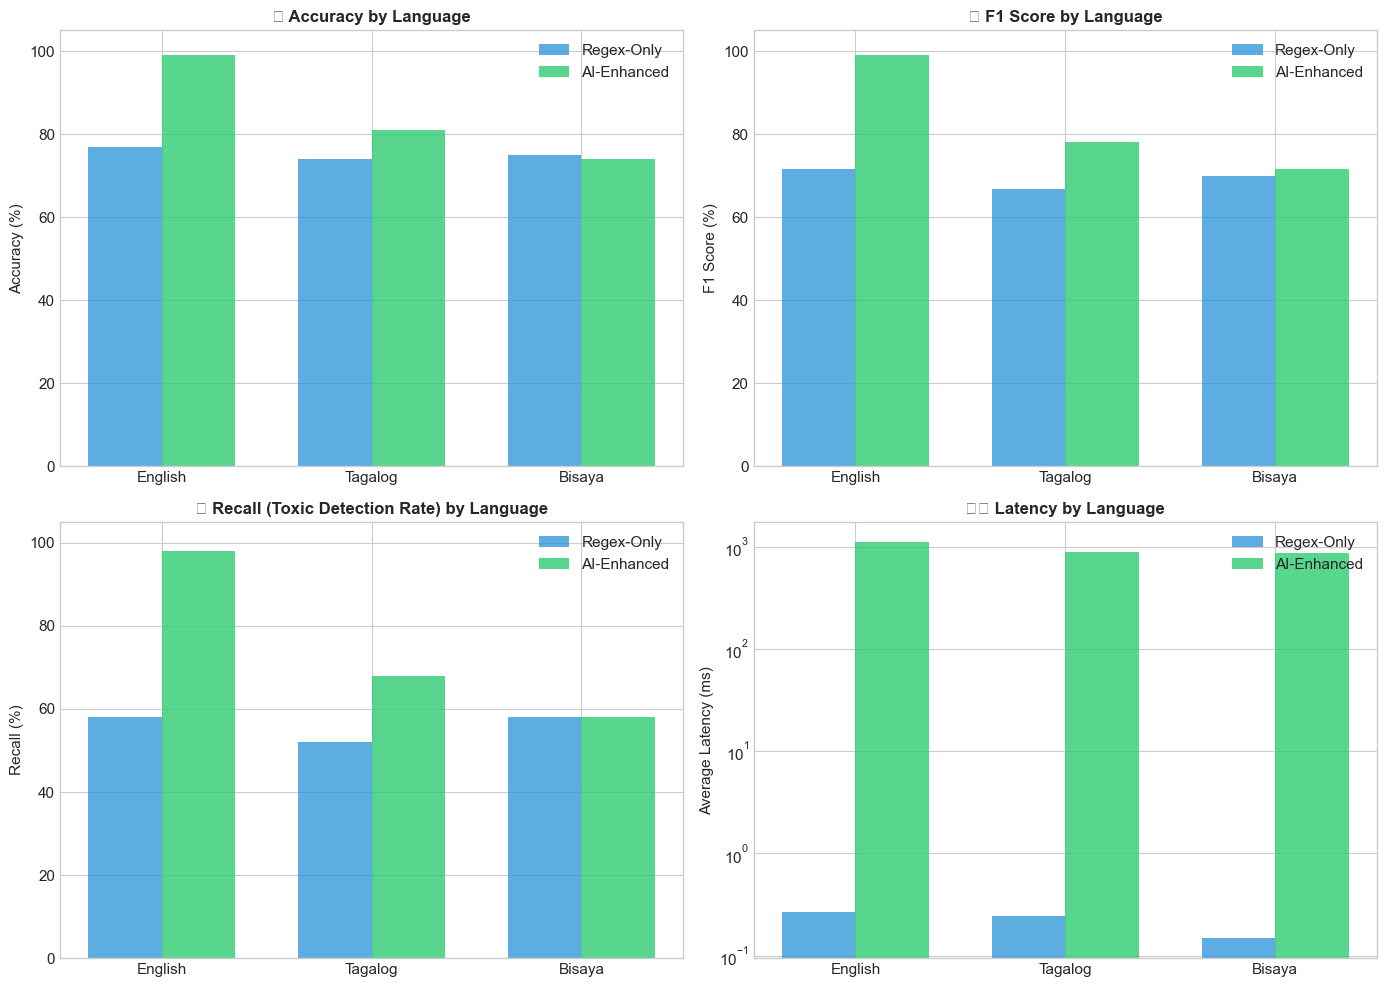


✅ Chart saved to tests/results/language_comparison.png


In [8]:
# Prepare language data
languages = ['english', 'tagalog', 'bisaya']
lang_labels = ['English', 'Tagalog', 'Bisaya']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy comparison
regex_acc = [regex_results.languages[l].accuracy for l in languages]
ai_acc = [ai_results.languages[l].accuracy for l in languages]

x = np.arange(len(languages))
width = 0.35

axes[0, 0].bar(x - width/2, regex_acc, width, label='Regex-Only', color=COLORS['regex'], alpha=0.8)
axes[0, 0].bar(x + width/2, ai_acc, width, label='AI-Enhanced', color=COLORS['ai'], alpha=0.8)
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_title('🎯 Accuracy by Language', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(lang_labels)
axes[0, 0].legend()
axes[0, 0].set_ylim(0, 105)

# F1 Score comparison
regex_f1 = [regex_results.languages[l].f1_score for l in languages]
ai_f1 = [ai_results.languages[l].f1_score for l in languages]

axes[0, 1].bar(x - width/2, regex_f1, width, label='Regex-Only', color=COLORS['regex'], alpha=0.8)
axes[0, 1].bar(x + width/2, ai_f1, width, label='AI-Enhanced', color=COLORS['ai'], alpha=0.8)
axes[0, 1].set_ylabel('F1 Score (%)')
axes[0, 1].set_title('📊 F1 Score by Language', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(lang_labels)
axes[0, 1].legend()
axes[0, 1].set_ylim(0, 105)

# Recall (Toxic Detection Rate) comparison
regex_recall = [regex_results.languages[l].recall for l in languages]
ai_recall = [ai_results.languages[l].recall for l in languages]

axes[1, 0].bar(x - width/2, regex_recall, width, label='Regex-Only', color=COLORS['regex'], alpha=0.8)
axes[1, 0].bar(x + width/2, ai_recall, width, label='AI-Enhanced', color=COLORS['ai'], alpha=0.8)
axes[1, 0].set_ylabel('Recall (%)')
axes[1, 0].set_title('🔍 Recall (Toxic Detection Rate) by Language', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(lang_labels)
axes[1, 0].legend()
axes[1, 0].set_ylim(0, 105)

# Latency comparison (log scale for visibility)
regex_latency = [regex_results.languages[l].avg_latency_ms for l in languages]
ai_latency = [ai_results.languages[l].avg_latency_ms for l in languages]

axes[1, 1].bar(x - width/2, regex_latency, width, label='Regex-Only', color=COLORS['regex'], alpha=0.8)
axes[1, 1].bar(x + width/2, ai_latency, width, label='AI-Enhanced', color=COLORS['ai'], alpha=0.8)
axes[1, 1].set_ylabel('Average Latency (ms)')
axes[1, 1].set_title('⏱️ Latency by Language', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(lang_labels)
axes[1, 1].legend()
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.savefig('../tests/results/language_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved to tests/results/language_comparison.png")

## 7. Category Performance Analysis

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10332\2608782513.py:43: UserWarning: Glyph 128194 (\N{OPEN FILE FOLDER}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10332\2608782513.py:44: UserWarning: Glyph 128194 (\N{OPEN FILE FOLDER}) missing from font(s) Arial.
  plt.savefig('../tests/results/category_comparison.png', dpi=150, bbox_inches='tight')
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128194 (\N{OPEN FILE FOLDER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


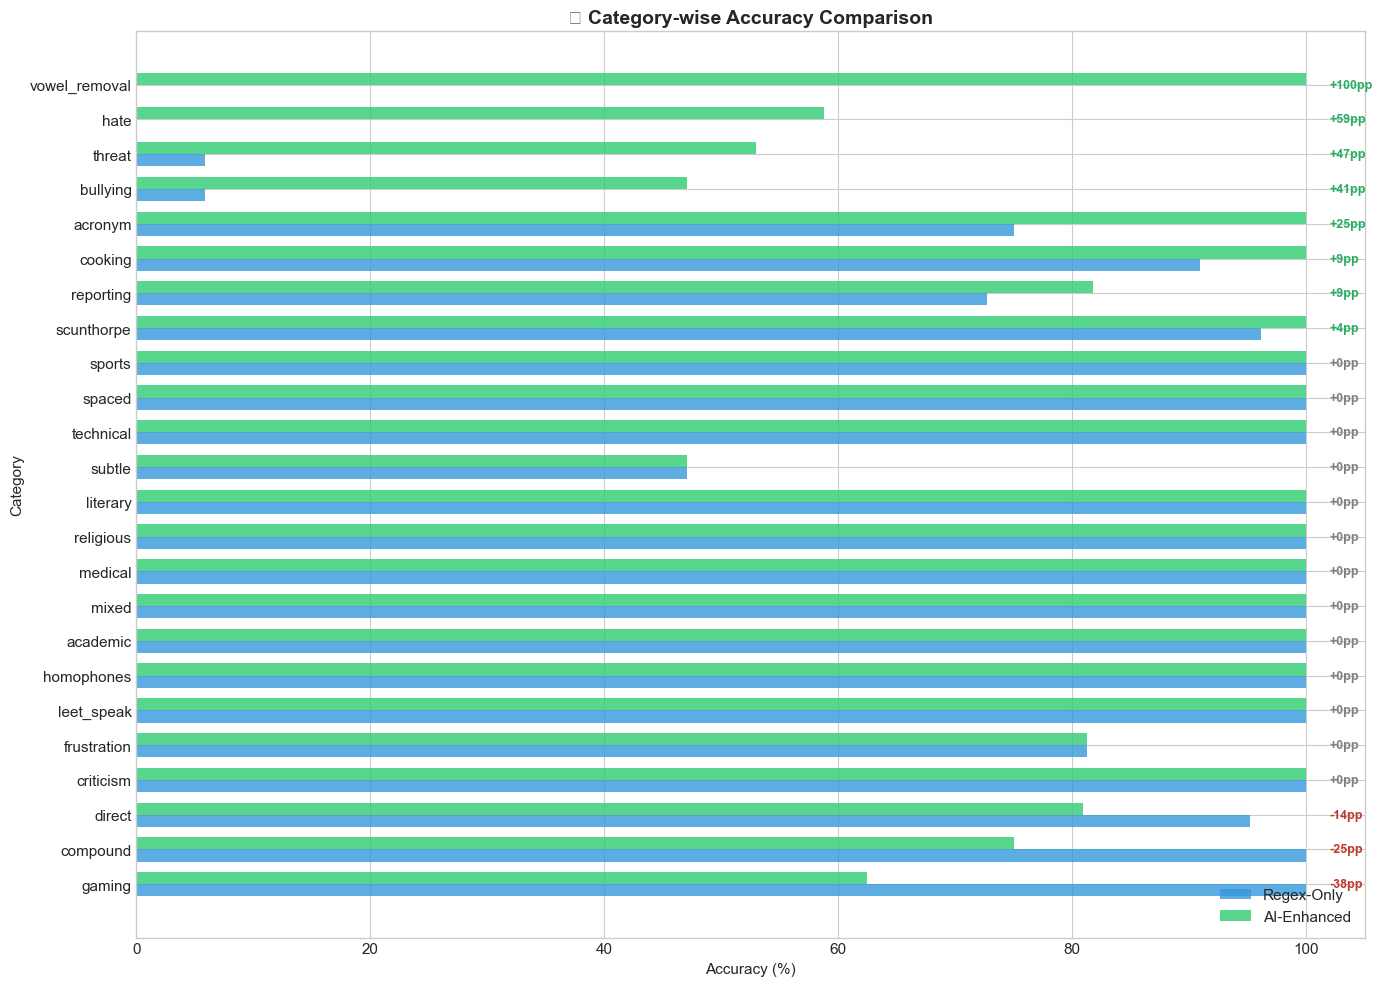


✅ Chart saved to tests/results/category_comparison.png


In [9]:
# Get all categories and sort by AI accuracy
all_categories = set(regex_results.categories.keys()) | set(ai_results.categories.keys())
all_categories = sorted(all_categories)

# Prepare data
cat_data = []
for cat in all_categories:
    regex_cat = regex_results.categories.get(cat)
    ai_cat = ai_results.categories.get(cat)
    cat_data.append({
        'Category': cat,
        'Regex Accuracy': regex_cat.accuracy if regex_cat else 0,
        'AI Accuracy': ai_cat.accuracy if ai_cat else 0,
        'Improvement': (ai_cat.accuracy if ai_cat else 0) - (regex_cat.accuracy if regex_cat else 0)
    })

cat_df = pd.DataFrame(cat_data)
cat_df = cat_df.sort_values('Improvement', ascending=True)

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(14, 10))

y = np.arange(len(cat_df))
height = 0.35

bars1 = ax.barh(y - height/2, cat_df['Regex Accuracy'], height, label='Regex-Only', color=COLORS['regex'], alpha=0.8)
bars2 = ax.barh(y + height/2, cat_df['AI Accuracy'], height, label='AI-Enhanced', color=COLORS['ai'], alpha=0.8)

ax.set_xlabel('Accuracy (%)')
ax.set_ylabel('Category')
ax.set_title('📂 Category-wise Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_yticks(y)
ax.set_yticklabels(cat_df['Category'])
ax.legend(loc='lower right')
ax.set_xlim(0, 105)

# Add improvement labels
for i, (_, row) in enumerate(cat_df.iterrows()):
    imp = row['Improvement']
    color = COLORS['correct'] if imp > 0 else (COLORS['incorrect'] if imp < 0 else 'gray')
    ax.annotate(f'{imp:+.0f}pp', xy=(102, i), fontsize=9, color=color, fontweight='bold', va='center')

plt.tight_layout()
plt.savefig('../tests/results/category_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved to tests/results/category_comparison.png")

## 8. Error Analysis: False Positives vs False Negatives

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10332\4147720261.py:49: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10332\4147720261.py:49: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10332\4147720261.py:50: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.savefig('../tests/results/error_analysis.png', dpi=150, bbox_inches='tight')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10332\4147720261.py:50: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  plt.savefig('../tests/results/error_analysis.png', dpi=150, bbox_inches='tight')
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  

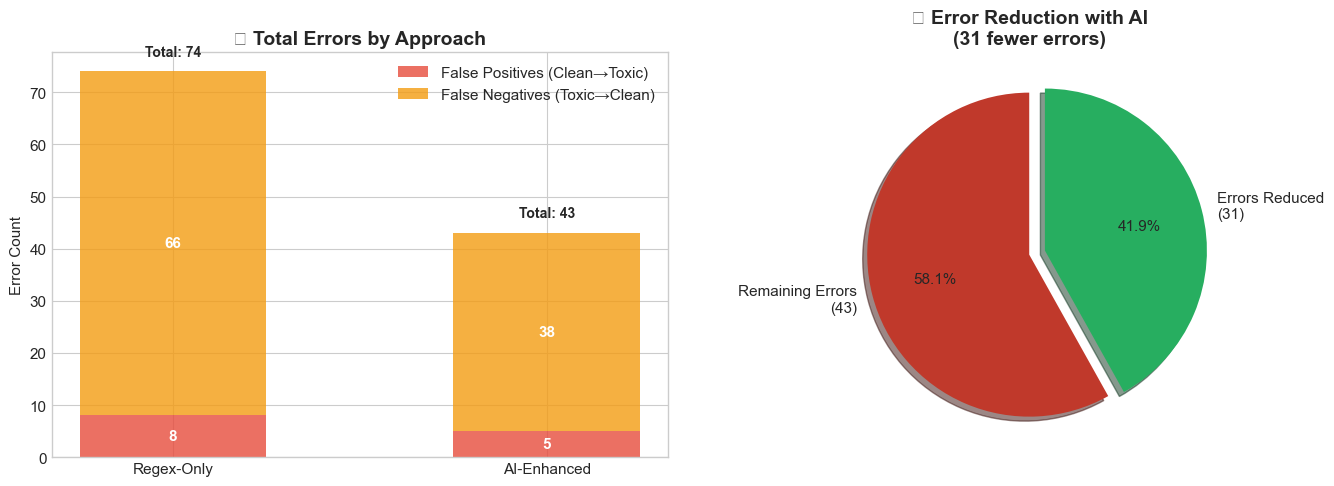


📊 Error Reduction Summary:
   Regex-Only Total Errors: 74
   AI-Enhanced Total Errors: 43
   Errors Reduced: 31 (41.9% reduction)


In [10]:
# Error breakdown
error_data = {
    'Approach': ['Regex-Only', 'Regex-Only', 'AI-Enhanced', 'AI-Enhanced'],
    'Error Type': ['False Positives', 'False Negatives', 'False Positives', 'False Negatives'],
    'Count': [regex_results.false_positives, regex_results.false_negatives, 
              ai_results.false_positives, ai_results.false_negatives]
}
error_df = pd.DataFrame(error_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar chart
approaches = ['Regex-Only', 'AI-Enhanced']
fp_counts = [regex_results.false_positives, ai_results.false_positives]
fn_counts = [regex_results.false_negatives, ai_results.false_negatives]

x = np.arange(len(approaches))
width = 0.5

bars1 = axes[0].bar(x, fp_counts, width, label='False Positives (Clean→Toxic)', color='#e74c3c', alpha=0.8)
bars2 = axes[0].bar(x, fn_counts, width, bottom=fp_counts, label='False Negatives (Toxic→Clean)', color='#f39c12', alpha=0.8)

axes[0].set_ylabel('Error Count')
axes[0].set_title('❌ Total Errors by Approach', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(approaches)
axes[0].legend(loc='upper right')

# Add labels
for i, (fp, fn) in enumerate(zip(fp_counts, fn_counts)):
    axes[0].annotate(f'{fp}', xy=(i, fp/2), ha='center', va='center', color='white', fontweight='bold')
    axes[0].annotate(f'{fn}', xy=(i, fp + fn/2), ha='center', va='center', color='white', fontweight='bold')
    axes[0].annotate(f'Total: {fp+fn}', xy=(i, fp + fn + 3), ha='center', fontsize=10, fontweight='bold')

# Error reduction pie chart
total_regex_errors = regex_results.false_positives + regex_results.false_negatives
total_ai_errors = ai_results.false_positives + ai_results.false_negatives
errors_reduced = total_regex_errors - total_ai_errors

sizes = [total_ai_errors, errors_reduced]
labels = [f'Remaining Errors\n({total_ai_errors})', f'Errors Reduced\n({errors_reduced})']
colors_pie = [COLORS['incorrect'], COLORS['correct']]
explode = (0, 0.1)

axes[1].pie(sizes, explode=explode, labels=labels, colors=colors_pie, autopct='%1.1f%%',
            shadow=True, startangle=90, textprops={'fontsize': 11})
axes[1].set_title(f'📉 Error Reduction with AI\n({errors_reduced} fewer errors)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../tests/results/error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Error Reduction Summary:")
print(f"   Regex-Only Total Errors: {total_regex_errors}")
print(f"   AI-Enhanced Total Errors: {total_ai_errors}")
print(f"   Errors Reduced: {errors_reduced} ({errors_reduced/total_regex_errors*100:.1f}% reduction)")

## 9. Latency vs Accuracy Trade-off

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10332\585643509.py:35: UserWarning: Glyph 9878 (\N{SCALES}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10332\585643509.py:35: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10332\585643509.py:36: UserWarning: Glyph 9878 (\N{SCALES}) missing from font(s) Arial.
  plt.savefig('../tests/results/latency_accuracy_tradeoff.png', dpi=150, bbox_inches='tight')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10332\585643509.py:36: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.savefig('../tests/results/latency_accuracy_tradeoff.png', dpi=150, bbox_inches='tight')
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9878 (\N{SCALES}) missing from font(s) Arial.
  fig.canva

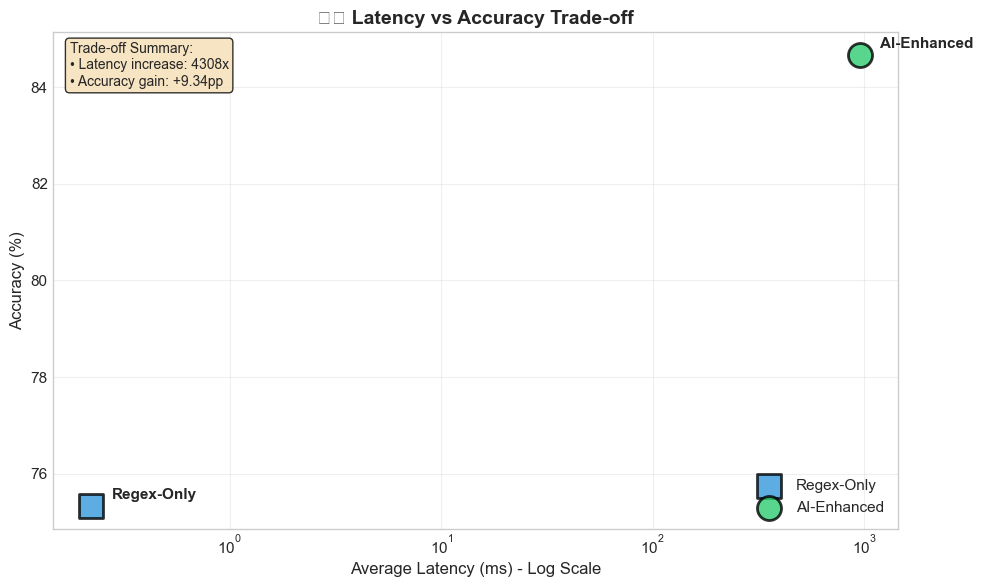


✅ Chart saved to tests/results/latency_accuracy_tradeoff.png


In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

# Data points for each approach
approaches_data = [
    {'name': 'Regex-Only', 'latency': regex_results.avg_latency_ms, 
     'accuracy': regex_results.accuracy, 'color': COLORS['regex'], 'marker': 's'},
    {'name': 'AI-Enhanced', 'latency': ai_results.avg_latency_ms, 
     'accuracy': ai_results.accuracy, 'color': COLORS['ai'], 'marker': 'o'}
]

for data in approaches_data:
    ax.scatter(data['latency'], data['accuracy'], s=300, c=data['color'], 
               marker=data['marker'], label=data['name'], edgecolors='black', linewidth=2, alpha=0.8)
    ax.annotate(data['name'], xy=(data['latency'], data['accuracy']),
                xytext=(15, 5), textcoords='offset points', fontsize=11, fontweight='bold')

ax.set_xlabel('Average Latency (ms) - Log Scale', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('⚖️ Latency vs Accuracy Trade-off', fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# Add annotations for trade-off
latency_increase = ai_results.avg_latency_ms / regex_results.avg_latency_ms
accuracy_gain = ai_results.accuracy - regex_results.accuracy

textstr = f'Trade-off Summary:\n' \
          f'• Latency increase: {latency_increase:.0f}x\n' \
          f'• Accuracy gain: +{accuracy_gain:.2f}pp'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('../tests/results/latency_accuracy_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved to tests/results/latency_accuracy_tradeoff.png")

## 10. Summary Dashboard

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10332\3821078894.py:92: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) Arial.
  plt.savefig('../tests/results/summary_dashboard.png', dpi=150, bbox_inches='tight')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10332\3821078894.py:92: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.savefig('../tests/results/summary_dashboard.png', dpi=150, bbox_inches='tight')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10332\3821078894.py:92: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) Arial.
  plt.savefig('../tests/results/summary_dashboard.png', dpi=150, bbox_inches='tight')
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\IPyt

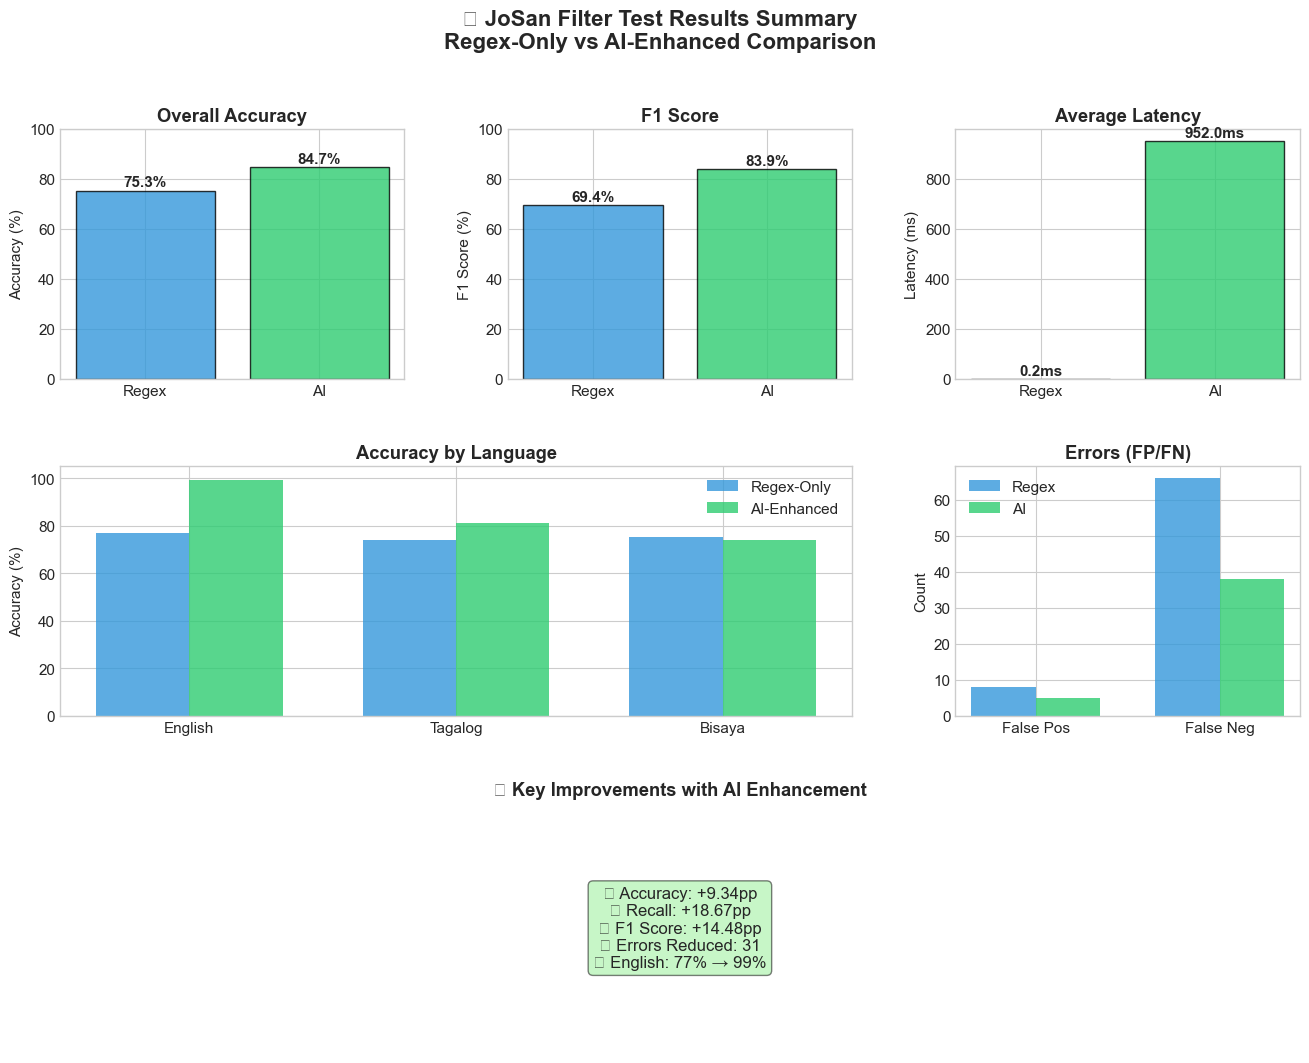


✅ Summary dashboard saved to tests/results/summary_dashboard.png


In [12]:
fig = plt.figure(figsize=(16, 12))

# Create grid layout
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# Title
fig.suptitle('🌐 JoSan Filter Test Results Summary\nRegex-Only vs AI-Enhanced Comparison', 
             fontsize=16, fontweight='bold', y=0.98)

# 1. Overall Accuracy (top left)
ax1 = fig.add_subplot(gs[0, 0])
approaches = ['Regex', 'AI']
accuracies = [regex_results.accuracy, ai_results.accuracy]
colors_bar = [COLORS['regex'], COLORS['ai']]
bars = ax1.bar(approaches, accuracies, color=colors_bar, alpha=0.8, edgecolor='black')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Overall Accuracy', fontweight='bold')
ax1.set_ylim(0, 100)
for bar in bars:
    ax1.annotate(f'{bar.get_height():.1f}%', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 xytext=(0, 3), textcoords="offset points", ha='center', fontsize=11, fontweight='bold')

# 2. F1 Score (top center)
ax2 = fig.add_subplot(gs[0, 1])
f1_scores = [regex_results.f1_score, ai_results.f1_score]
bars = ax2.bar(approaches, f1_scores, color=colors_bar, alpha=0.8, edgecolor='black')
ax2.set_ylabel('F1 Score (%)')
ax2.set_title('F1 Score', fontweight='bold')
ax2.set_ylim(0, 100)
for bar in bars:
    ax2.annotate(f'{bar.get_height():.1f}%', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 xytext=(0, 3), textcoords="offset points", ha='center', fontsize=11, fontweight='bold')

# 3. Latency (top right)
ax3 = fig.add_subplot(gs[0, 2])
latencies = [regex_results.avg_latency_ms, ai_results.avg_latency_ms]
bars = ax3.bar(approaches, latencies, color=colors_bar, alpha=0.8, edgecolor='black')
ax3.set_ylabel('Latency (ms)')
ax3.set_title('Average Latency', fontweight='bold')
for bar in bars:
    ax3.annotate(f'{bar.get_height():.1f}ms', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 xytext=(0, 3), textcoords="offset points", ha='center', fontsize=11, fontweight='bold')

# 4. Language Accuracy (middle row, spans 2 columns)
ax4 = fig.add_subplot(gs[1, :2])
languages = ['English', 'Tagalog', 'Bisaya']
lang_keys = ['english', 'tagalog', 'bisaya']
regex_lang_acc = [regex_results.languages[l].accuracy for l in lang_keys]
ai_lang_acc = [ai_results.languages[l].accuracy for l in lang_keys]

x = np.arange(len(languages))
width = 0.35
ax4.bar(x - width/2, regex_lang_acc, width, label='Regex-Only', color=COLORS['regex'], alpha=0.8)
ax4.bar(x + width/2, ai_lang_acc, width, label='AI-Enhanced', color=COLORS['ai'], alpha=0.8)
ax4.set_ylabel('Accuracy (%)')
ax4.set_title('Accuracy by Language', fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(languages)
ax4.legend()
ax4.set_ylim(0, 105)

# 5. Error breakdown (middle right)
ax5 = fig.add_subplot(gs[1, 2])
error_types = ['FP', 'FN']
regex_errors = [regex_results.false_positives, regex_results.false_negatives]
ai_errors = [ai_results.false_positives, ai_results.false_negatives]
x = np.arange(len(error_types))
ax5.bar(x - width/2, regex_errors, width, label='Regex', color=COLORS['regex'], alpha=0.8)
ax5.bar(x + width/2, ai_errors, width, label='AI', color=COLORS['ai'], alpha=0.8)
ax5.set_ylabel('Count')
ax5.set_title('Errors (FP/FN)', fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(['False Pos', 'False Neg'])
ax5.legend()

# 6. Key Improvements (bottom row, spans all columns)
ax6 = fig.add_subplot(gs[2, :])
improvements = [
    f"Accuracy: +{ai_results.accuracy - regex_results.accuracy:.2f}pp",
    f"Recall: +{ai_results.recall - regex_results.recall:.2f}pp",
    f"F1 Score: +{ai_results.f1_score - regex_results.f1_score:.2f}pp",
    f"Errors Reduced: {(regex_results.false_positives + regex_results.false_negatives) - (ai_results.false_positives + ai_results.false_negatives)}",
    f"English: {regex_results.languages['english'].accuracy:.0f}% → {ai_results.languages['english'].accuracy:.0f}%"
]
text = "\n".join([f"✅ {imp}" for imp in improvements])
ax6.text(0.5, 0.5, text, transform=ax6.transAxes, fontsize=12,
         verticalalignment='center', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
ax6.set_title('🚀 Key Improvements with AI Enhancement', fontweight='bold')
ax6.axis('off')

plt.savefig('../tests/results/summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Summary dashboard saved to tests/results/summary_dashboard.png")

## 11. Export Results as Tables

In [13]:
# Create summary comparison table
summary_data = {
    'Metric': ['Overall Accuracy', 'Precision', 'Recall', 'F1 Score', 'Avg Latency', 
               'False Positives', 'False Negatives', 'Total Errors'],
    'Regex-Only': [
        f"{regex_results.accuracy:.2f}%",
        f"{regex_results.precision:.2f}%",
        f"{regex_results.recall:.2f}%",
        f"{regex_results.f1_score:.2f}%",
        f"{regex_results.avg_latency_ms:.3f}ms",
        str(regex_results.false_positives),
        str(regex_results.false_negatives),
        str(regex_results.false_positives + regex_results.false_negatives)
    ],
    'AI-Enhanced': [
        f"{ai_results.accuracy:.2f}%",
        f"{ai_results.precision:.2f}%",
        f"{ai_results.recall:.2f}%",
        f"{ai_results.f1_score:.2f}%",
        f"{ai_results.avg_latency_ms:.3f}ms",
        str(ai_results.false_positives),
        str(ai_results.false_negatives),
        str(ai_results.false_positives + ai_results.false_negatives)
    ],
    'Improvement': [
        f"+{ai_results.accuracy - regex_results.accuracy:.2f}pp",
        f"+{ai_results.precision - regex_results.precision:.2f}pp",
        f"+{ai_results.recall - regex_results.recall:.2f}pp",
        f"+{ai_results.f1_score - regex_results.f1_score:.2f}pp",
        f"{ai_results.avg_latency_ms / regex_results.avg_latency_ms:.0f}x slower",
        f"{ai_results.false_positives - regex_results.false_positives:+d}",
        f"{ai_results.false_negatives - regex_results.false_negatives:+d}",
        f"{(ai_results.false_positives + ai_results.false_negatives) - (regex_results.false_positives + regex_results.false_negatives):+d}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n📊 OVERALL COMPARISON TABLE")
print("=" * 70)
print(summary_df.to_string(index=False))

# Save to CSV
summary_df.to_csv('../tests/results/comparison_summary.csv', index=False)
print("\n✅ Saved to tests/results/comparison_summary.csv")


📊 OVERALL COMPARISON TABLE
          Metric Regex-Only AI-Enhanced  Improvement
Overall Accuracy     75.33%      84.67%      +9.34pp
       Precision     91.30%      95.73%      +4.43pp
          Recall     56.00%      74.67%     +18.67pp
        F1 Score     69.42%      83.90%     +14.48pp
     Avg Latency    0.221ms   952.000ms 4308x slower
 False Positives          8           5           -3
 False Negatives         66          38          -28
    Total Errors         74          43          -31

✅ Saved to tests/results/comparison_summary.csv


In [14]:
# Per-language comparison table
lang_comparison = []
for lang in ['english', 'tagalog', 'bisaya']:
    regex_lang = regex_results.languages[lang]
    ai_lang = ai_results.languages[lang]
    lang_comparison.append({
        'Language': lang.capitalize(),
        'Regex Accuracy': f"{regex_lang.accuracy:.1f}%",
        'AI Accuracy': f"{ai_lang.accuracy:.1f}%",
        'Regex F1': f"{regex_lang.f1_score:.1f}%",
        'AI F1': f"{ai_lang.f1_score:.1f}%",
        'Regex Latency': f"{regex_lang.avg_latency_ms:.3f}ms",
        'AI Latency': f"{ai_lang.avg_latency_ms:.0f}ms",
        'Accuracy Δ': f"+{ai_lang.accuracy - regex_lang.accuracy:.1f}pp"
    })

lang_df = pd.DataFrame(lang_comparison)
print("\n🌐 PER-LANGUAGE COMPARISON")
print("=" * 100)
print(lang_df.to_string(index=False))

# Save to CSV
lang_df.to_csv('../tests/results/language_comparison.csv', index=False)
print("\n✅ Saved to tests/results/language_comparison.csv")


🌐 PER-LANGUAGE COMPARISON
Language Regex Accuracy AI Accuracy Regex F1 AI F1 Regex Latency AI Latency Accuracy Δ
 English          77.0%       99.0%    71.6% 99.0%       0.267ms     1110ms    +22.0pp
 Tagalog          74.0%       81.0%    66.7% 78.2%       0.246ms      884ms     +7.0pp
  Bisaya          75.0%       74.0%    69.9% 71.6%       0.148ms      861ms    +-1.0pp

✅ Saved to tests/results/language_comparison.csv


## 12. Conclusions

In [15]:
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                        📊 TEST RESULTS CONCLUSIONS                           ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  🎯 OVERALL IMPROVEMENT                                                      ║
║  ─────────────────────────────────────────────────────────────────────────── ║""")

acc_improvement = ai_results.accuracy - regex_results.accuracy
recall_improvement = ai_results.recall - regex_results.recall
f1_improvement = ai_results.f1_score - regex_results.f1_score
error_reduction = (regex_results.false_positives + regex_results.false_negatives) - \
                  (ai_results.false_positives + ai_results.false_negatives)
latency_factor = ai_results.avg_latency_ms / regex_results.avg_latency_ms

print(f"║  • Accuracy improved by: +{acc_improvement:.2f} percentage points")
print(f"║  • Recall (toxic detection) improved by: +{recall_improvement:.2f} percentage points")
print(f"║  • F1 Score improved by: +{f1_improvement:.2f} percentage points")
print(f"║  • Total errors reduced by: {error_reduction} ({error_reduction/(regex_results.false_positives + regex_results.false_negatives)*100:.1f}%)")
print(f"║  • Latency trade-off: {latency_factor:.0f}x slower")
print("║                                                                              ║")

print("""║  🌐 LANGUAGE-SPECIFIC INSIGHTS                                               ║
║  ─────────────────────────────────────────────────────────────────────────── ║""")

for lang in ['english', 'tagalog', 'bisaya']:
    regex_lang = regex_results.languages[lang]
    ai_lang = ai_results.languages[lang]
    improvement = ai_lang.accuracy - regex_lang.accuracy
    print(f"║  • {lang.capitalize():8}: {regex_lang.accuracy:.1f}% → {ai_lang.accuracy:.1f}% (+{improvement:.1f}pp)")

print("""║                                                                              ║
║  💡 KEY TAKEAWAYS                                                            ║
║  ─────────────────────────────────────────────────────────────────────────── ║
║  1. AI enhancement provides significant accuracy improvements                ║
║  2. English sees the largest improvement (regex struggles with context)      ║
║  3. Regex excels at explicit profanity but misses contextual toxicity        ║
║  4. AI helps with hate speech, threats, and subtle bullying detection        ║
║  5. Trade-off: ~4000x latency increase for ~10pp accuracy gain               ║
║                                                                              ║
║  🔧 RECOMMENDATIONS                                                          ║
║  ─────────────────────────────────────────────────────────────────────────── ║
║  • Use hybrid approach: fast regex pre-filter + AI for ambiguous cases      ║
║  • Implement caching to reduce API calls for repeated content                ║
║  • Consider async AI processing for non-blocking UX                          ║
║  • Expand regex patterns for vowel_removal and threat categories             ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║                        📊 TEST RESULTS CONCLUSIONS                           ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  🎯 OVERALL IMPROVEMENT                                                      ║
║  ─────────────────────────────────────────────────────────────────────────── ║
║  • Accuracy improved by: +9.34 percentage points
║  • Recall (toxic detection) improved by: +18.67 percentage points
║  • F1 Score improved by: +14.48 percentage points
║  • Total errors reduced by: 31 (41.9%)
║  • Latency trade-off: 4308x slower
║                                                                              ║
║  🌐 LANGUAGE-SPECIFIC INSIGHTS                                               ║
║  ─────────────────────────────────────────────────────────────────────────── ║
║  • English : 77.0% → 9